# ============================================================
# TECH CHALLENGE - FASE 1
# Diagnóstico de Câncer de Mama com Machine Learning
# Dataset: Breast Cancer Wisconsin (UCI / Kaggle)
# ============================================================

In [6]:
# --- Instalação (rode só se necessário) ---
# !pip install shap

# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
import shap

import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Imports OK")

✅ Imports OK


# 📥 Carregando o dataset

In [7]:
df = pd.read_csv('data.csv')
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)  # colunas desnecessárias
df['diagnosis'] = df['diagnosis'].map({'M': 0, 'B': 1})

# Primeiros registros
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 🔍 Olhando os dados

In [14]:
print(f"Shape do dataset: {df.shape}")
print(f"\nDistribuição da variável alvo:")
print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

df.info()
df.describe()

Shape do dataset: (569, 31)

Distribuição da variável alvo:
diagnosis
1    357
0    212
Name: count, dtype: int64
diagnosis
1    62.7%
0    37.3%
Name: proportion, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se               

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.627417,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,1.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# 📊 Análise Exploratória (EDA)
## 2.1 — Distribuição da variável alvo (gráfico)

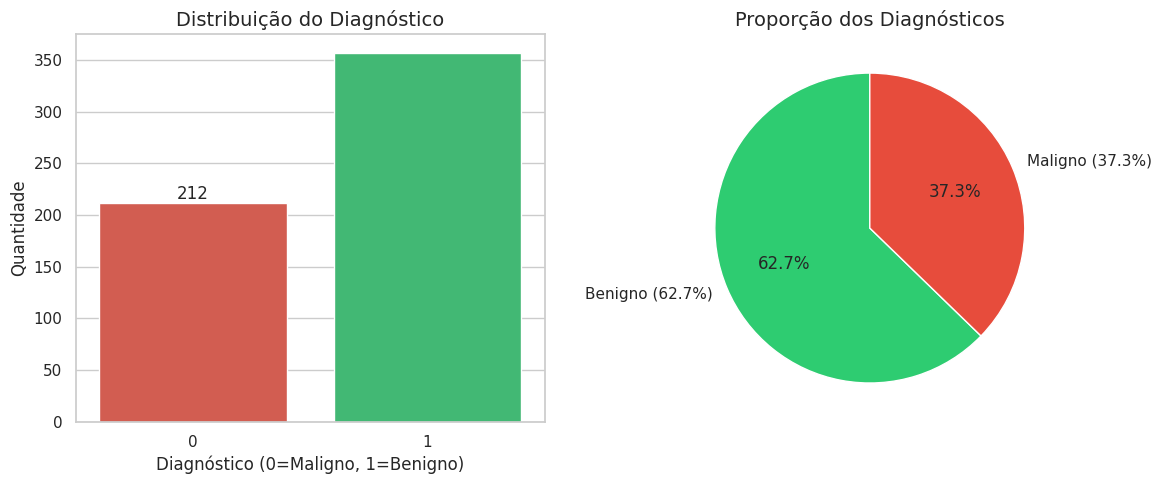

In [13]:
# --- 2.1 Distribuição da variável alvo ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Contagem
sns.countplot(x='diagnosis', data=df, palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Distribuição do Diagnóstico', fontsize=14)
axes[0].set_xlabel('Diagnóstico (0=Maligno, 1=Benigno)')
axes[0].set_ylabel('Quantidade')
axes[0].bar_label(axes[0].containers[0])

# Proporção
axes[1].pie(
    df['diagnosis'].value_counts(),
    labels=['Benigno (62.7%)', 'Maligno (37.3%)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporção dos Diagnósticos', fontsize=14)

plt.tight_layout()
plt.savefig('distribuicao_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 — Distribuição das features por diagnóstico

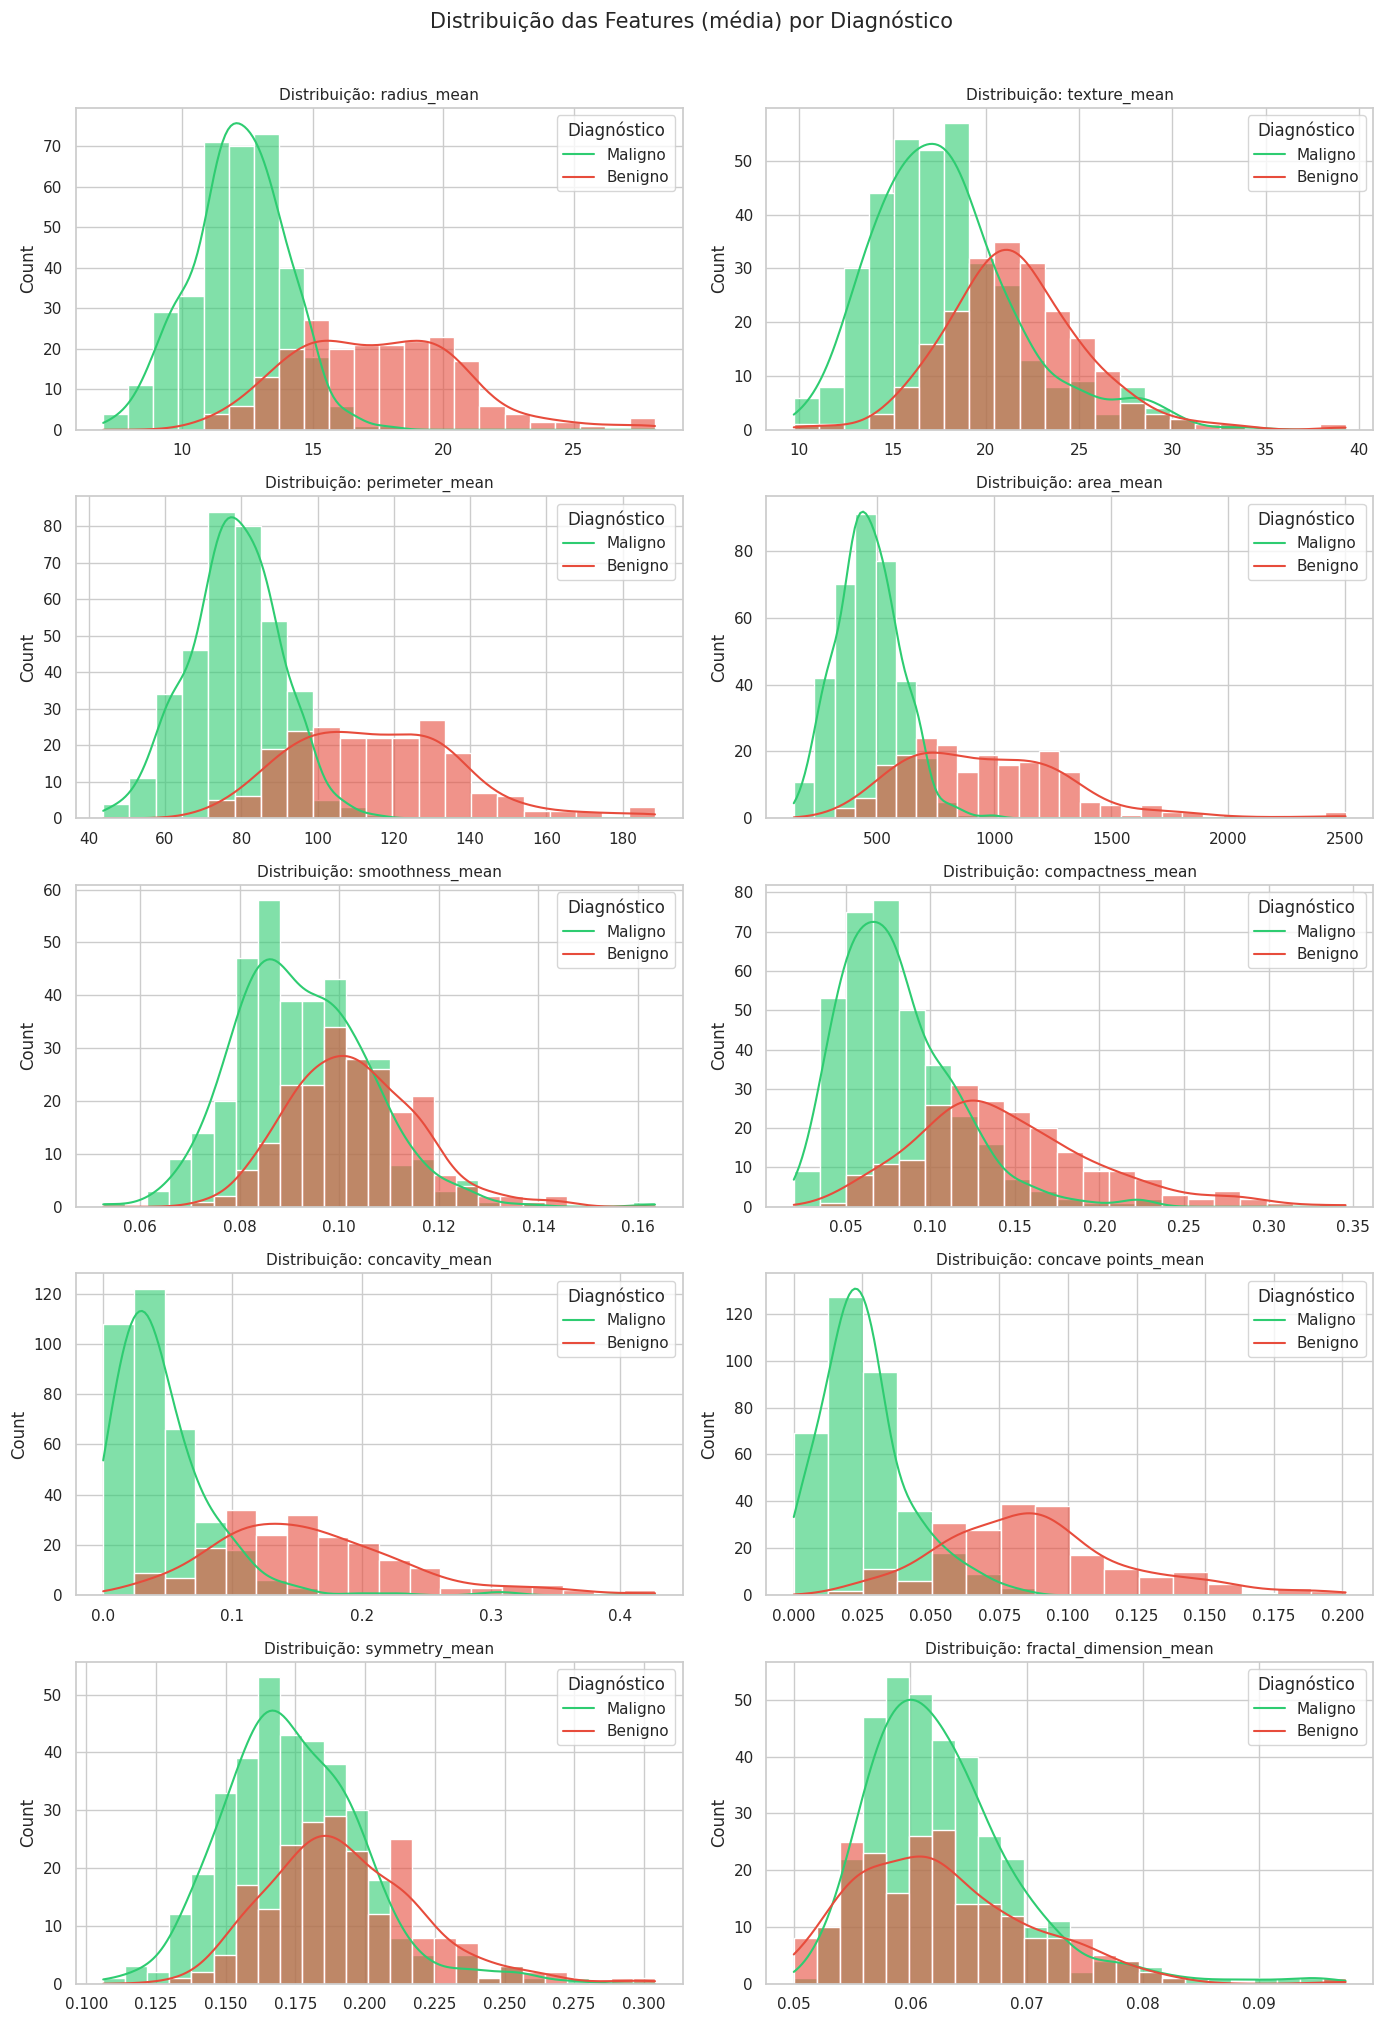

In [15]:
# --- 2.2 Distribuição das features _mean por diagnóstico ---
mean_cols = [col for col in df.columns if '_mean' in col]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(mean_cols):
    sns.histplot(
        data=df, x=col, hue='diagnosis',
        palette=['#e74c3c', '#2ecc71'],
        kde=True, ax=axes[i], alpha=0.6
    )
    axes[i].set_title(f'Distribuição: {col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].legend(labels=['Maligno', 'Benigno'], title='Diagnóstico')

plt.suptitle('Distribuição das Features (média) por Diagnóstico', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('distribuicao_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 — Boxplots para detectar outliers

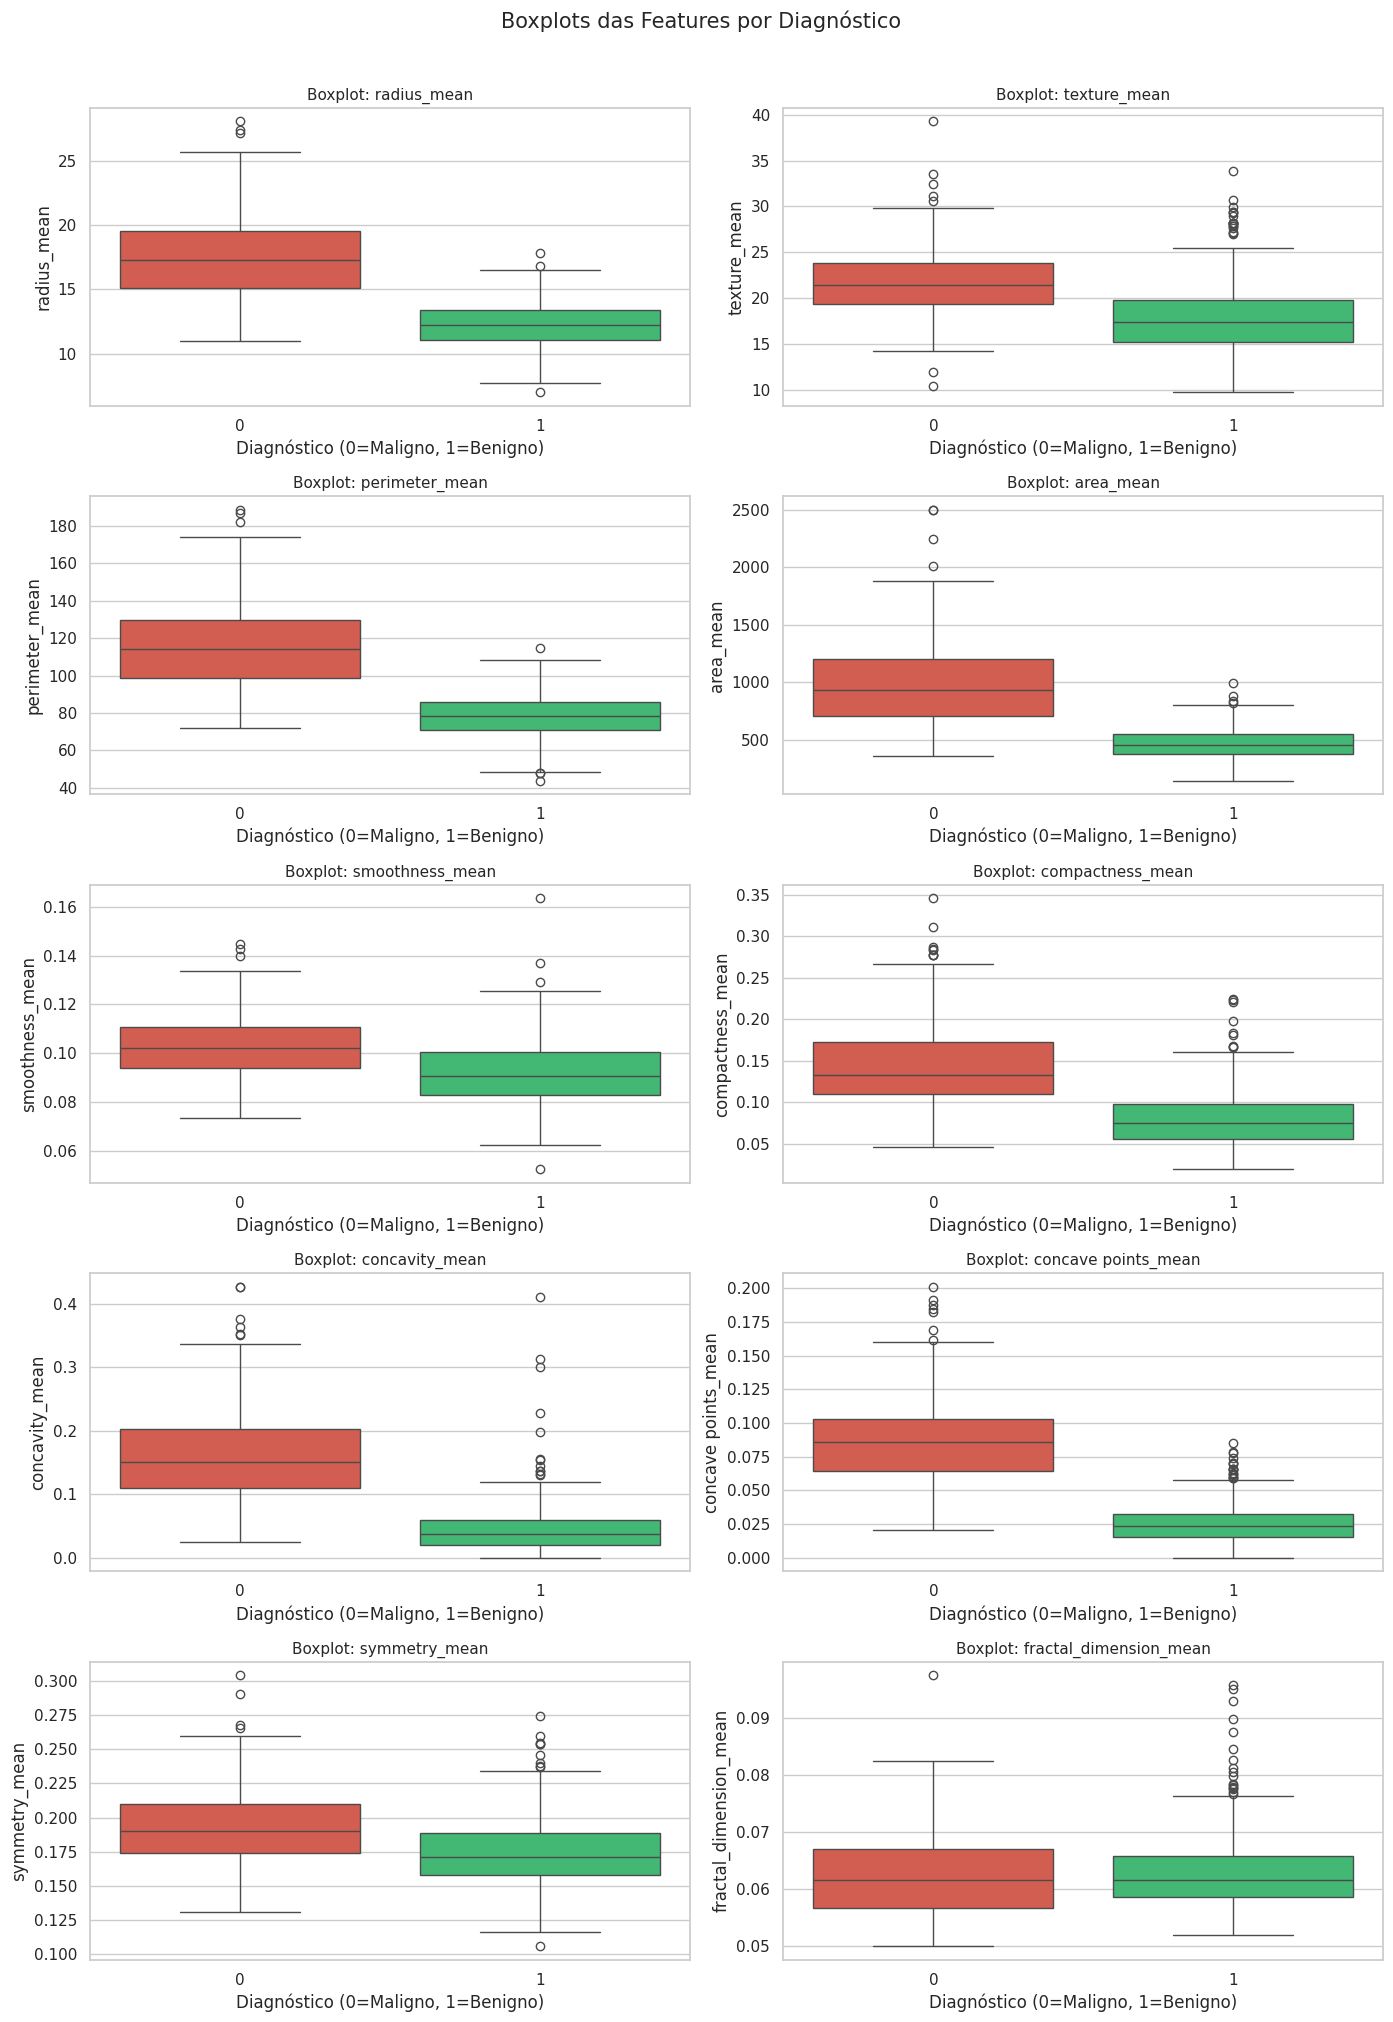

In [16]:
# --- 2.3 Boxplots das features _mean ---
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(mean_cols):
    sns.boxplot(
        data=df, x='diagnosis', y=col,
        palette=['#e74c3c', '#2ecc71'], ax=axes[i]
    )
    axes[i].set_title(f'Boxplot: {col}', fontsize=11)
    axes[i].set_xlabel('Diagnóstico (0=Maligno, 1=Benigno)')

plt.suptitle('Boxplots das Features por Diagnóstico', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('boxplots_features.png', dpi=150, bbox_inches='tight')
plt.show()

Nos gráficos boxsplots observa-se uma presença considerável de outliers, porém, no contexto médico outliers podem significar casos raros, e não somente valores incorretos.

## 2.4 — Estatísticas descritivas por grupo

In [17]:
# --- 2.4 Estatísticas descritivas por diagnóstico ---
print("=== MÉDIAS POR DIAGNÓSTICO ===\n")
resumo = df.groupby('diagnosis')[mean_cols].mean().T
resumo.columns = ['Maligno (0)', 'Benigno (1)']
resumo['Diferença %'] = ((resumo['Maligno (0)'] - resumo['Benigno (1)'])
                          / resumo['Benigno (1)'] * 100).round(1).astype(str) + '%'
print(resumo.to_string())

=== MÉDIAS POR DIAGNÓSTICO ===

                        Maligno (0)  Benigno (1) Diferença %
radius_mean               17.462830    12.146524       43.8%
texture_mean              21.604906    17.914762       20.6%
perimeter_mean           115.365377    78.075406       47.8%
area_mean                978.376415   462.790196      111.4%
smoothness_mean            0.102898     0.092478       11.3%
compactness_mean           0.145188     0.080085       81.3%
concavity_mean             0.160775     0.046058      249.1%
concave points_mean        0.087990     0.025717      242.1%
symmetry_mean              0.192909     0.174186       10.7%
fractal_dimension_mean     0.062680     0.062867       -0.3%


Podemos observar que as características perimeter_mean, area_mean, radius_mean e concave points_mean, possuem diferenças consideráveis entre elas. Biologicamente falando tumores malignos tendem a ser maiores e com bordas mais irregulares

# 🔧 Pré-processamento

## 3.1 — Verificação de valores ausentes e duplicatas

In [20]:
# --- 3.1 Checagem de qualidade dos dados ---
print("=== VALORES AUSENTES ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ Nenhum valor ausente encontrado!\n")

print("\n=== DUPLICATAS ===")
duplicatas = df.duplicated().sum()
print(f"✅ {duplicatas} linhas duplicadas encontradas.")

print("\n=== TIPOS DE DADOS ===")
print(df.dtypes.value_counts())

=== VALORES AUSENTES ===
✅ Nenhum valor ausente encontrado!


=== DUPLICATAS ===
✅ 0 linhas duplicadas encontradas.

=== TIPOS DE DADOS ===
float64    30
int64       1
Name: count, dtype: int64


## 3.2 — Separação features vs alvo

In [21]:
# --- 3.2 Separando X (features) e y (alvo) ---
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print(f"Features (X): {X.shape}")
print(f"Alvo    (y): {y.shape}")
print(f"\nColunas usadas como features: {list(X.columns)}")

Features (X): (569, 30)
Alvo    (y): (569,)

Colunas usadas como features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


## 3.3 — Normalização com StandardScaler

In [22]:
# --- 3.3 Normalização ---
# Por que normalizar?
# Features como area_mean (valores ~500) dominam sobre smoothness_mean (~0.1)
# O StandardScaler coloca tudo na mesma escala: média 0, desvio padrão 1
# Isso é ESSENCIAL para Regressão Logística e reduz impacto dos outliers

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print("Antes da normalização:")
print(X[['area_mean', 'smoothness_mean']].describe().round(3))

print("\nDepois da normalização:")
print(X_scaled[['area_mean', 'smoothness_mean']].describe().round(3))

Antes da normalização:
       area_mean  smoothness_mean
count    569.000          569.000
mean     654.889            0.096
std      351.914            0.014
min      143.500            0.053
25%      420.300            0.086
50%      551.100            0.096
75%      782.700            0.105
max     2501.000            0.163

Depois da normalização:
       area_mean  smoothness_mean
count    569.000          569.000
mean      -0.000           -0.000
std        1.001            1.001
min       -1.454           -3.112
25%       -0.667           -0.711
50%       -0.295           -0.035
75%        0.364            0.636
max        5.251            4.771


Escolhi o StandardScaler porque é mais robusto, ele não irá comprimir os dados num intervalo fixo [0,1].

## 3.4 — Análise de Correlação

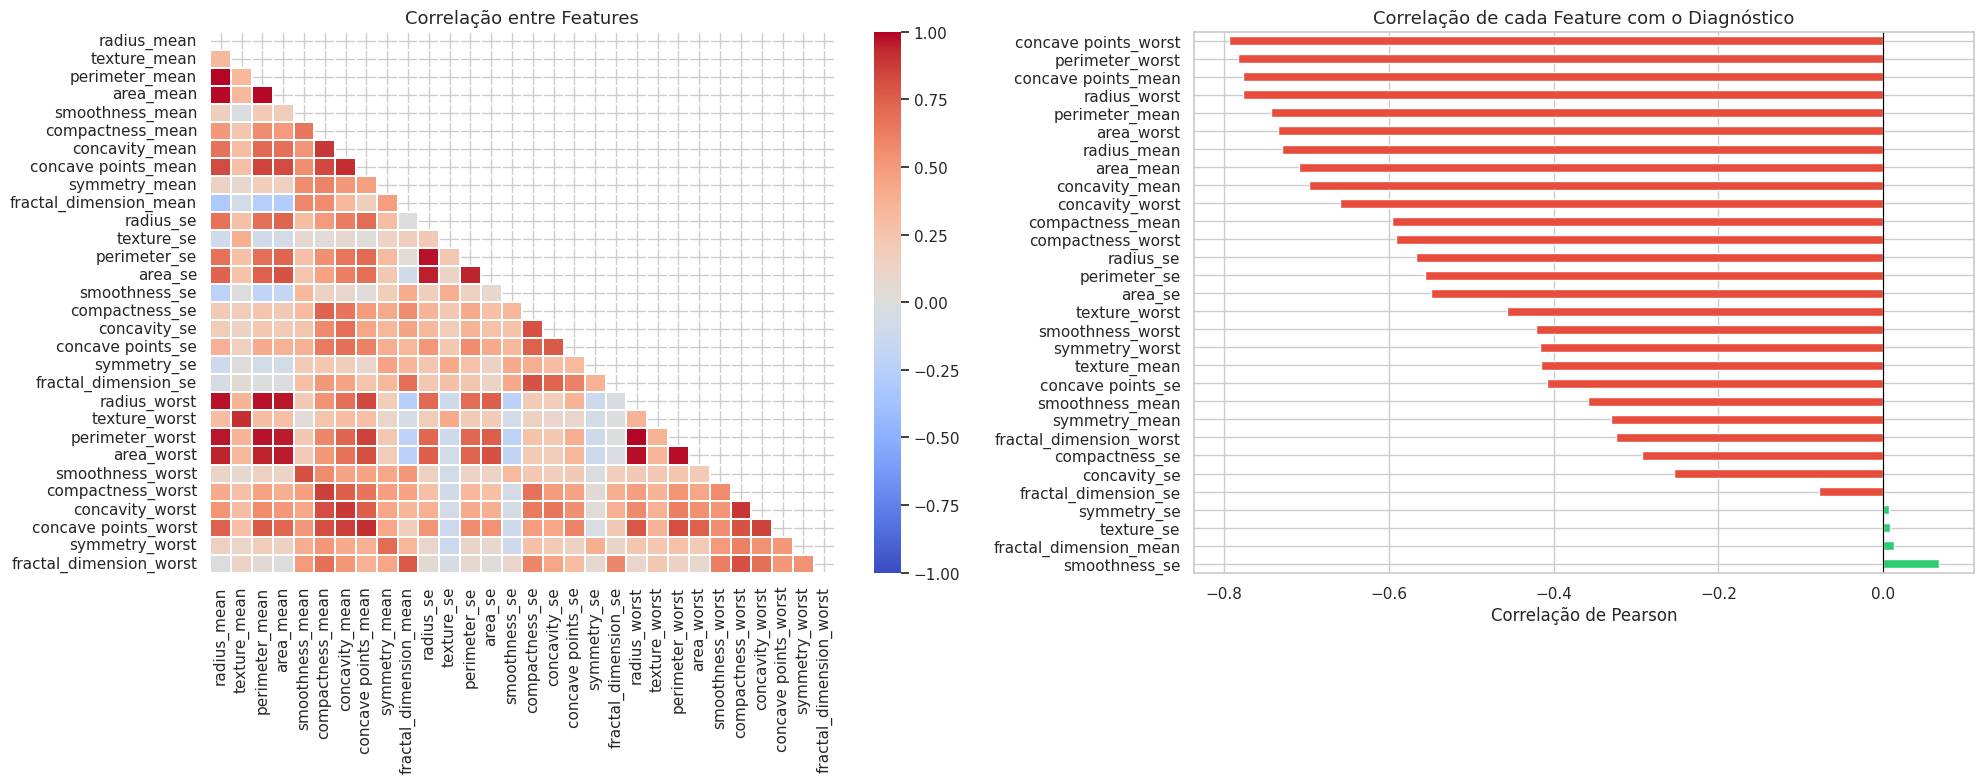


🔝 Top 10 features mais correlacionadas com o diagnóstico:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
concavity_mean          0.696
concavity_worst         0.660
dtype: float64


In [23]:
# --- 3.4 Matriz de Correlação ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Correlação geral entre features
corr_matrix = X_scaled.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # só triângulo inferior

sns.heatmap(
    corr_matrix, mask=mask, ax=axes[0],
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=False, linewidths=0.3
)
axes[0].set_title('Correlação entre Features', fontsize=13)

# Correlação de cada feature com o ALVO
corr_alvo = X_scaled.corrwith(y).sort_values(ascending=False)

corr_alvo.plot(kind='barh', ax=axes[1],
               color=['#2ecc71' if v > 0 else '#e74c3c' for v in corr_alvo])
axes[1].set_title('Correlação de cada Feature com o Diagnóstico', fontsize=13)
axes[1].set_xlabel('Correlação de Pearson')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features mais correlacionadas com o alvo
print("\n🔝 Top 10 features mais correlacionadas com o diagnóstico:")
print(corr_alvo.abs().sort_values(ascending=False).head(10).round(3))

Podemos observar que a correlação concave points(pontos côncavos) mede irregularidades na borda do tumor e tumores malignos tendem a ter bordas mais irregulares. Já o perimeter_worst(pior perímetro), reforçam que o tamanho e forma no pior caso são muito informativos

# ✂️ Divisão dos dados e Modelagem

## 4.1 — Split Treino/Teste

In [27]:
# --- 4.1 Divisão Treino / Teste ---
# Usamos stratify=y para garantir que a proporção 63/37 seja mantida
# em ambos os conjuntos — importante com dados levemente desbalanceados

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,       # 80% treino, 20% teste
    random_state=42,     # reprodutibilidade
    stratify=y           # mantém proporção das classes
)

print(f"Tamanho do treino : {X_train.shape[0]} amostras")
print(f"Tamanho do teste  : {X_test.shape[0]} amostras")

print(f"\nProporção no treino:")
print(y_train.value_counts(normalize=True).mul(100).round(1))
print(f"\nProporção no teste:")
print(y_test.value_counts(normalize=True).mul(100).round(1))

Tamanho do treino : 455 amostras
Tamanho do teste  : 114 amostras

Proporção no treino:
diagnosis
1    62.6
0    37.4
Name: proportion, dtype: float64

Proporção no teste:
diagnosis
1    63.2
0    36.8
Name: proportion, dtype: float64


## 4.2 — Definindo os modelos

In [28]:
# --- 4.2 Definição dos modelos ---
# Modelo 1: Regressão Logística
# - Simples, interpretável, boa baseline
# - C=1.0 é a regularização padrão (penaliza coeficientes muito grandes)
# - Lida bem com multicolinearidade por causa da regularização L2

modelo_lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Modelo 2: Random Forest
# - Conjunto de árvores de decisão (ensemble)
# - Robusto a outliers (como você identificou nos boxplots!)
# - Captura relações não-lineares entre features
# - Fornece feature importance nativamente

modelo_rf = RandomForestClassifier(
    n_estimators=100,   # 100 árvores
    max_depth=None,     # árvores crescem até separar bem os dados
    random_state=42
)

modelos = {
    'Regressão Logística': modelo_lr,
    'Random Forest': modelo_rf
}

print("✅ Modelos definidos:")
for nome, modelo in modelos.items():
    print(f"  → {nome}: {type(modelo).__name__}")

✅ Modelos definidos:
  → Regressão Logística: LogisticRegression
  → Random Forest: RandomForestClassifier


## 4.3 — Treinamento

In [29]:
# --- 4.3 Treinamento ---
print("🏋️ Treinando modelos...\n")

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    print(f"✅ {nome} treinado!")

🏋️ Treinando modelos...

✅ Regressão Logística treinado!
✅ Random Forest treinado!


## 4.4 — Avaliação completa

In [30]:
# --- 4.4 Função de avaliação ---
def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    acc    = accuracy_score(y_test, y_pred)
    rec    = recall_score(y_test, y_pred, pos_label=0)   # recall p/ MALIGNO
    f1     = f1_score(y_test, y_pred, pos_label=0)
    auc    = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*50}")
    print(f"  {nome}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f} ({acc*100:.1f}%)")
    print(f"  Recall   : {rec:.4f}  ← foco: detectar malignos!")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Maligno','Benigno'])}")

    return y_pred, y_prob

resultados = {}
for nome, modelo in modelos.items():
    y_pred, y_prob = avaliar_modelo(nome, modelo, X_test, y_test)
    resultados[nome] = {'pred': y_pred, 'prob': y_prob}


  Regressão Logística
  Accuracy : 0.9825 (98.2%)
  Recall   : 0.9762  ← foco: detectar malignos!
  F1-Score : 0.9762
  ROC-AUC  : 0.9954

              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


  Random Forest
  Accuracy : 0.9561 (95.6%)
  Recall   : 0.9286  ← foco: detectar malignos!
  F1-Score : 0.9398
  ROC-AUC  : 0.9937

              precision    recall  f1-score   support

     Maligno       0.95      0.93      0.94        42
     Benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



 Por que o Recall do Maligno é nossa métrica principal?
Pensa assim: um falso negativo (dizer que é benigno quando é maligno) é muito mais grave do que um falso positivo (alarme falso). No diagnóstico de câncer, deixar passar um caso maligno pode custar uma vida. Por isso maximizamos o Recall para a classe Maligno, mesmo que isso gere mais falsos alarmes.

## 4.5 — Matrizes de Confusão e Curvas ROC

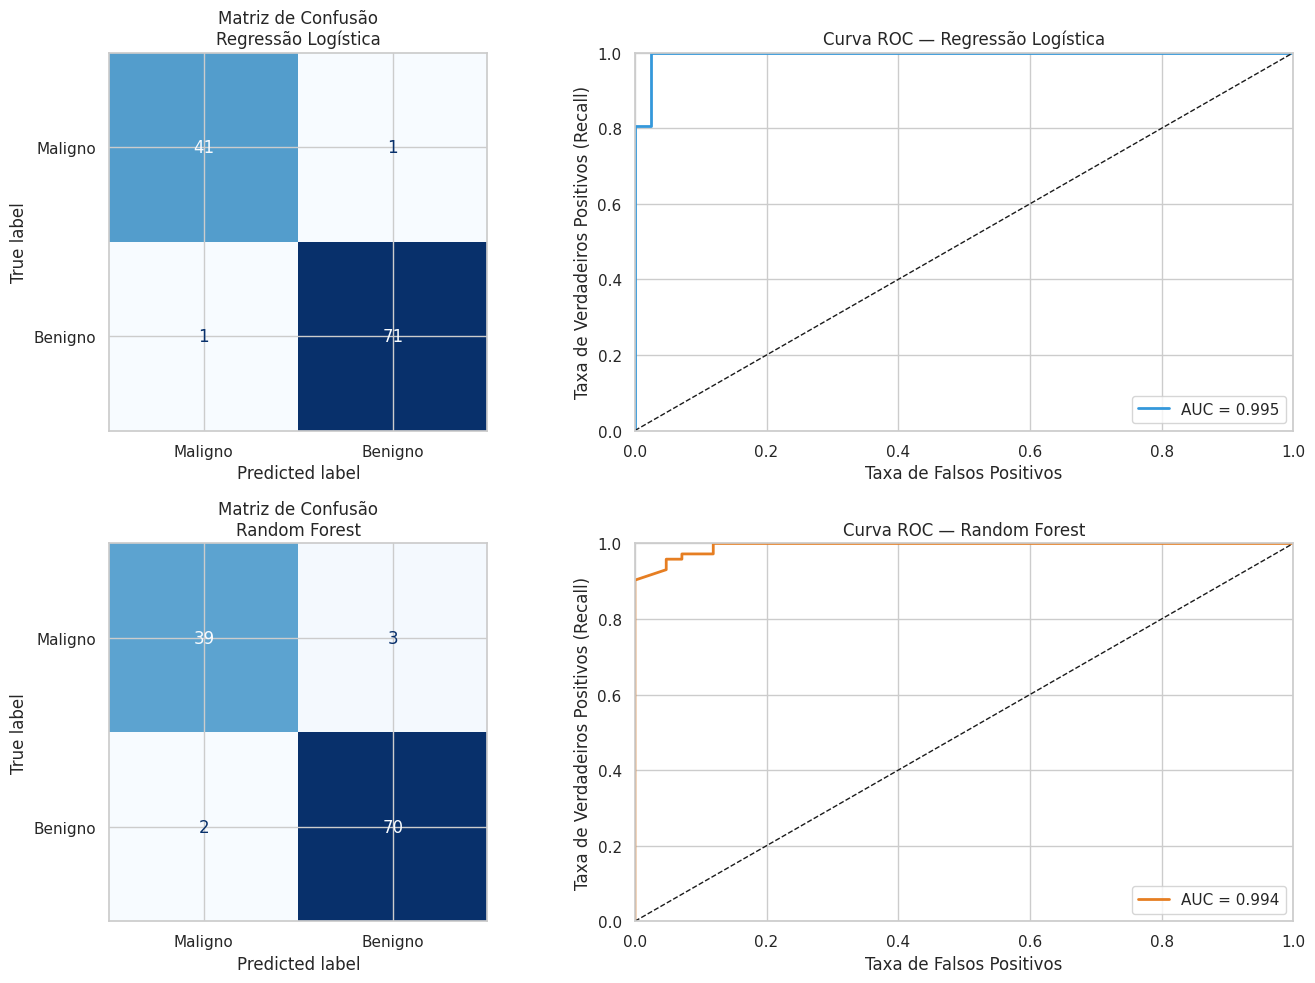

In [31]:
# --- 4.5 Visualizações de avaliação ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cores = ['#3498db', '#e67e22']

for idx, (nome, modelo) in enumerate(modelos.items()):
    y_pred = resultados[nome]['pred']
    y_prob = resultados[nome]['prob']

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Maligno', 'Benigno'])
    disp.plot(ax=axes[idx, 0], colorbar=False, cmap='Blues')
    axes[idx, 0].set_title(f'Matriz de Confusão\n{nome}', fontsize=12)

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
    auc = roc_auc_score(y_test, y_prob)
    axes[idx, 1].plot(fpr, tpr, color=cores[idx], lw=2,
                      label=f'AUC = {auc:.3f}')
    axes[idx, 1].plot([0,1],[0,1], 'k--', lw=1)
    axes[idx, 1].set_xlabel('Taxa de Falsos Positivos')
    axes[idx, 1].set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
    axes[idx, 1].set_title(f'Curva ROC — {nome}', fontsize=12)
    axes[idx, 1].legend(loc='lower right')
    axes[idx, 1].set_xlim([0, 1])
    axes[idx, 1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('avaliacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# 🔍 Explicabilidade (Feature Importance + SHAP)

## 5.1 — Feature Importance do Random Forest

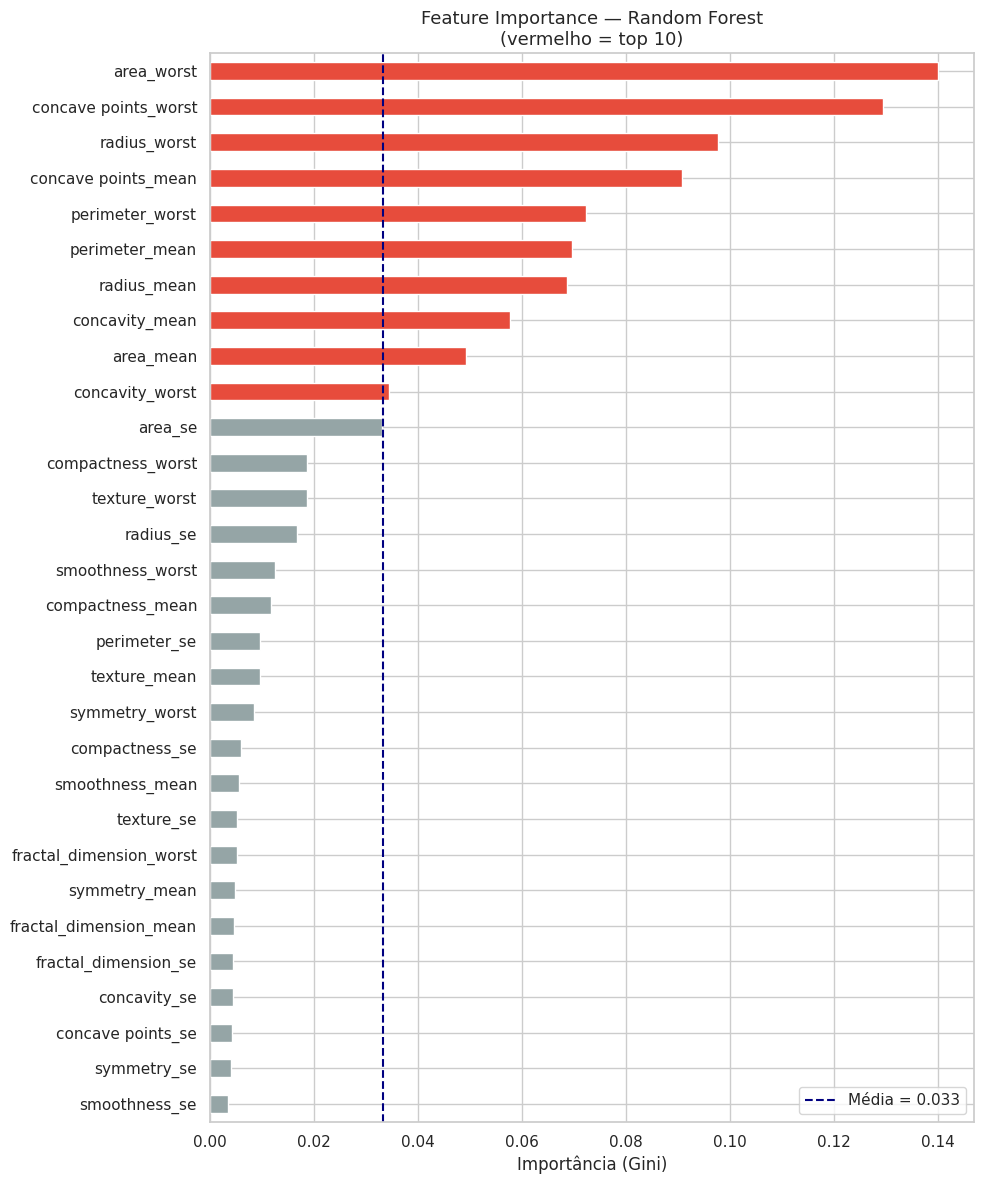

🔝 Top 10 features mais importantes (Random Forest):
area_worst              0.1400
concave points_worst    0.1295
radius_worst            0.0977
concave points_mean     0.0909
perimeter_worst         0.0722
perimeter_mean          0.0696
radius_mean             0.0687
concavity_mean          0.0576
area_mean               0.0492
concavity_worst         0.0343
dtype: float64


In [32]:
# --- 5.1 Feature Importance (Random Forest) ---
# O Random Forest calcula naturalmente a importância de cada feature
# baseado em quantas vezes ela foi usada para dividir os dados
# e o quanto cada divisão reduziu a impureza (Gini)

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
cores_barras = ['#e74c3c' if i >= len(importancias)-10
                else '#95a5a6' for i in range(len(importancias))]

importancias.plot(kind='barh', ax=ax, color=cores_barras)
ax.set_title('Feature Importance — Random Forest\n(vermelho = top 10)', fontsize=13)
ax.set_xlabel('Importância (Gini)')
ax.axvline(importancias.mean(), color='navy', linestyle='--',
           label=f'Média = {importancias.mean():.3f}')
ax.legend()

plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("🔝 Top 10 features mais importantes (Random Forest):")
print(importancias.sort_values(ascending=False).head(10).round(4))

## 5.2 — Coeficientes da Regressão Logística

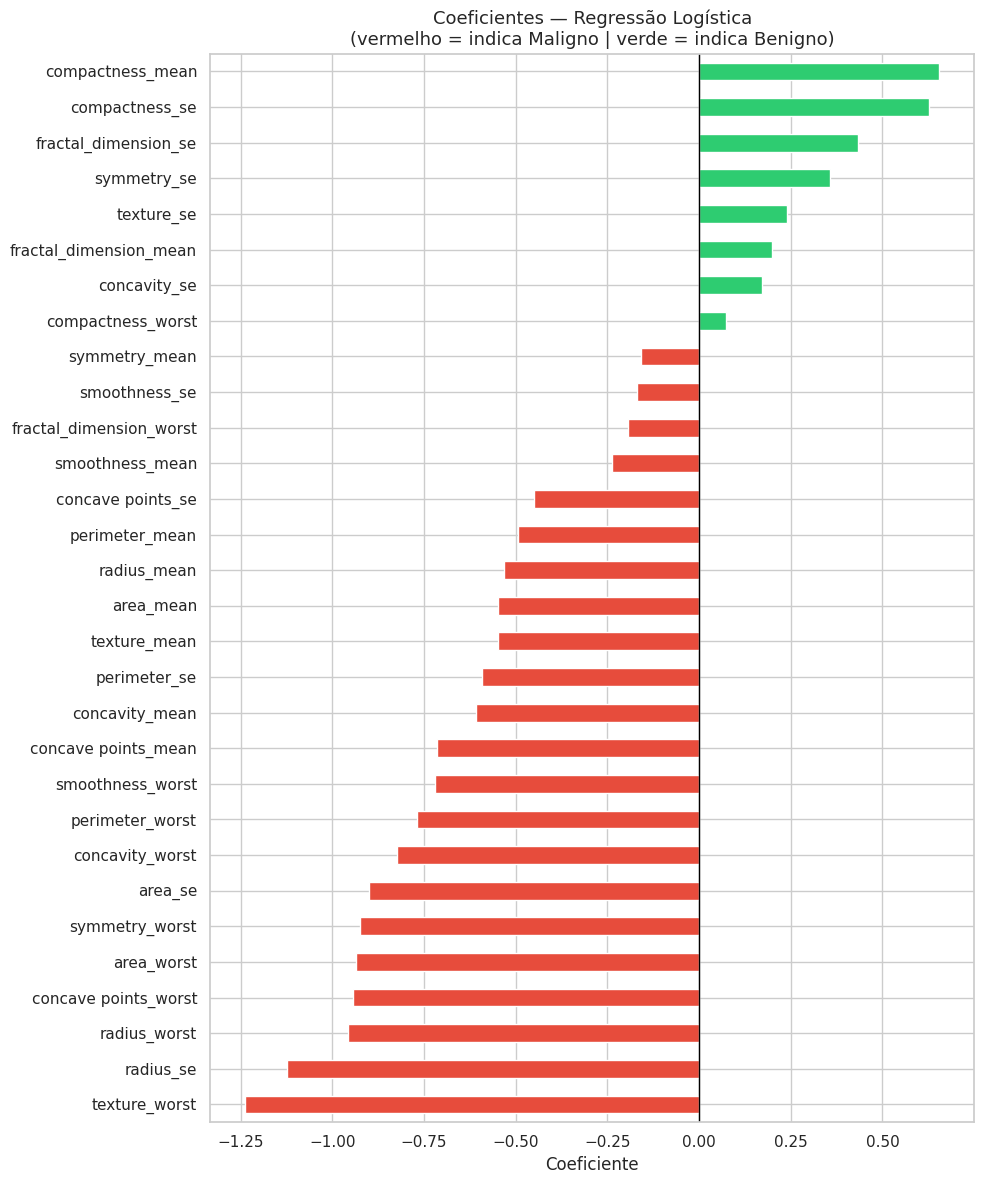


🔴 Top 5 features que mais indicam MALIGNO:
texture_worst          -1.2377
radius_se              -1.1233
radius_worst           -0.9563
concave points_worst   -0.9426
area_worst             -0.9360
dtype: float64

🟢 Top 5 features que mais indicam BENIGNO:
texture_se              0.2396
symmetry_se             0.3563
fractal_dimension_se    0.4342
compactness_se          0.6272
compactness_mean        0.6550
dtype: float64


In [33]:
# --- 5.2 Coeficientes da Regressão Logística ---
# Na Regressão Logística, o coeficiente de cada feature indica:
# - Positivo → aumenta a probabilidade de ser BENIGNO (classe 1)
# - Negativo → aumenta a probabilidade de ser MALIGNO (classe 0)
# - Magnitude → quanto mais longe de zero, mais influente

coefs = pd.Series(
    modelo_lr.coef_[0],
    index=X.columns
).sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
cores_coef = ['#e74c3c' if v < 0 else '#2ecc71' for v in coefs]

coefs.plot(kind='barh', ax=ax, color=cores_coef)
ax.set_title('Coeficientes — Regressão Logística\n(vermelho = indica Maligno | verde = indica Benigno)',
             fontsize=13)
ax.set_xlabel('Coeficiente')
ax.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig('coeficientes_lr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔴 Top 5 features que mais indicam MALIGNO:")
print(coefs.head(5).round(4))
print("\n🟢 Top 5 features que mais indicam BENIGNO:")
print(coefs.tail(5).round(4))

## 5.3 — SHAP Values (o mais importante para o relatório!)

⏳ Calculando SHAP values (pode demorar alguns segundos)...


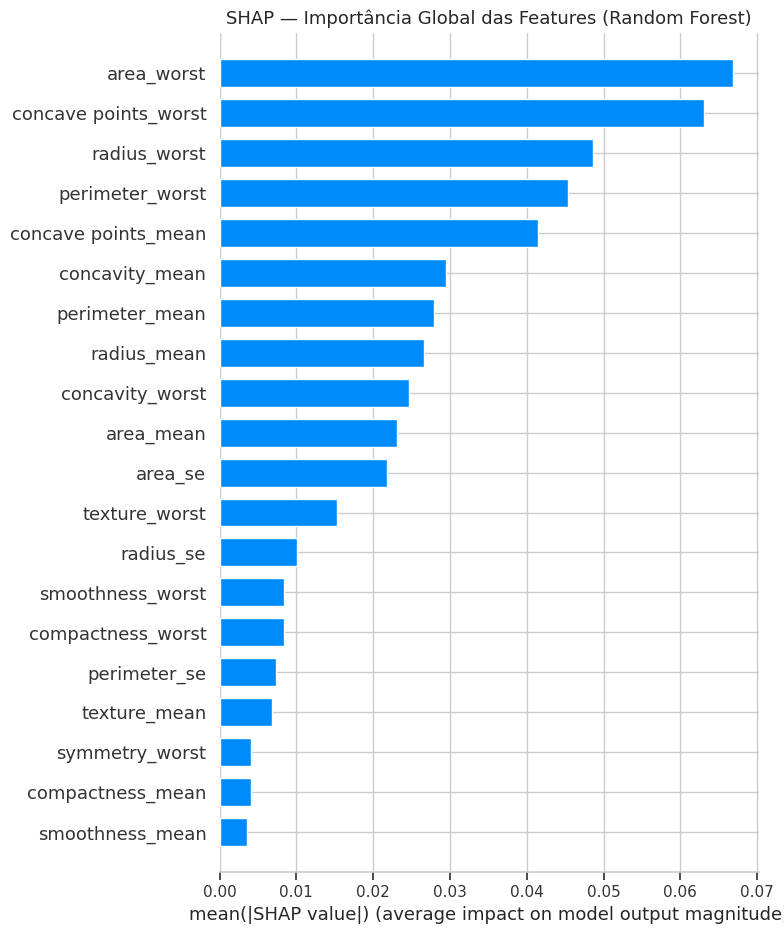

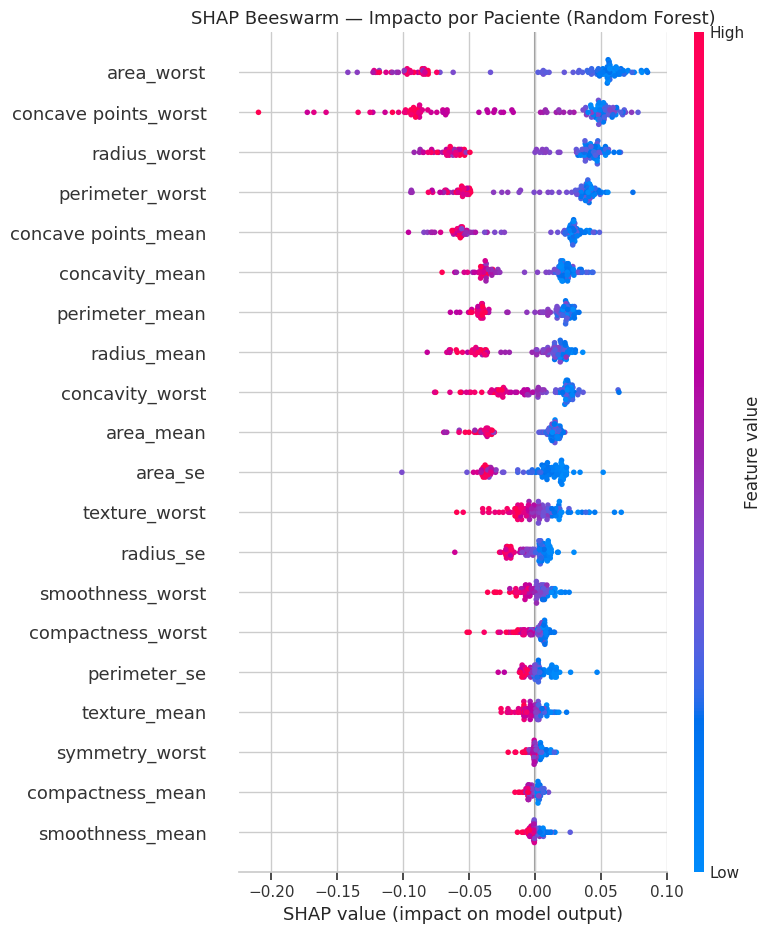

In [34]:
# --- 5.3 SHAP Values ---
# SHAP (SHapley Additive exPlanations) responde:
# "Para ESTE paciente específico, qual feature mais influenciou o diagnóstico?"
# É baseado em teoria dos jogos — cada feature recebe sua contribuição justa
# É considerado o estado da arte em explicabilidade de ML

print("⏳ Calculando SHAP values (pode demorar alguns segundos)...")

# Explicador para o Random Forest
explainer_rf = shap.TreeExplainer(modelo_rf)
shap_values_rf = explainer_rf.shap_values(X_test)

# Summary plot — visão geral de todas as features
plt.figure()
shap.summary_plot(
    shap_values_rf[:, :, 1],  # classe 1 = Benigno
    X_test,
    plot_type="bar",
    show=False
)
plt.title("SHAP — Importância Global das Features (Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot — mostra direção e magnitude por paciente
plt.figure()
shap.summary_plot(
    shap_values_rf[:, :, 1],
    X_test,
    show=False
)
plt.title("SHAP Beeswarm — Impacto por Paciente (Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# 📝 Comparativo Final e Discussão Crítica

## 6.1 — Tabela comparativa dos modelos

In [35]:
# --- 6.1 Tabela comparativa final ---
from sklearn.metrics import matthews_corrcoef

resultados_finais = []

for nome, modelo in modelos.items():
    y_pred = resultados[nome]['pred']
    y_prob  = resultados[nome]['prob']
    cm = confusion_matrix(y_test, y_pred)

    fn = cm[0, 1]  # falsos negativos (malignos classificados como benignos)
    fp = cm[1, 0]  # falsos positivos (benignos classificados como malignos)

    resultados_finais.append({
        'Modelo'             : nome,
        'Accuracy'           : accuracy_score(y_test, y_pred),
        'Recall (Maligno)'   : recall_score(y_test, y_pred, pos_label=0),
        'F1 (Maligno)'       : f1_score(y_test, y_pred, pos_label=0),
        'ROC-AUC'            : roc_auc_score(y_test, y_prob),
        'Falsos Negativos'   : fn,
        'Falsos Positivos'   : fp,
    })

df_resultados = pd.DataFrame(resultados_finais).set_index('Modelo')
print("=== COMPARATIVO FINAL DOS MODELOS ===\n")
print(df_resultados.round(4).to_string())

=== COMPARATIVO FINAL DOS MODELOS ===

                     Accuracy  Recall (Maligno)  F1 (Maligno)  ROC-AUC  Falsos Negativos  Falsos Positivos
Modelo                                                                                                    
Regressão Logística    0.9825            0.9762        0.9762   0.9954                 1                 1
Random Forest          0.9561            0.9286        0.9398   0.9937                 3                 2


## 6.2 — Gráfico comparativo

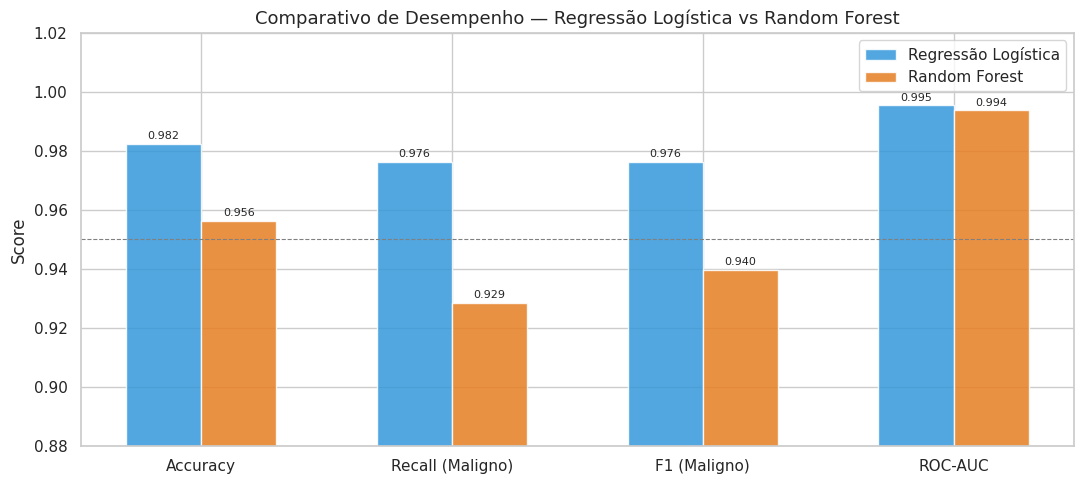

In [36]:
# --- 6.2 Visualização comparativa ---
metricas = ['Accuracy', 'Recall (Maligno)', 'F1 (Maligno)', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(metricas))
width = 0.3
cores_mod = ['#3498db', '#e67e22']

for i, (nome, row) in enumerate(df_resultados.iterrows()):
    valores = [row[m] for m in metricas]
    bars = ax.bar(x + i * width, valores, width, label=nome,
                  color=cores_mod[i], alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0.88, 1.02)
ax.set_ylabel('Score')
ax.set_title('Comparativo de Desempenho — Regressão Logística vs Random Forest', fontsize=13)
ax.legend()
ax.axhline(0.95, color='gray', linestyle='--', linewidth=0.8, label='Linha 95%')

plt.tight_layout()
plt.savefig('comparativo_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# Relatório Final

## 💬 Discussão Crítica dos Resultados

### Desempenho dos modelos
Ambos os modelos apresentaram desempenho elevado. A **Regressão Logística**
obteve resultados superiores ao **Random Forest** neste dataset, com Accuracy
de 98.2% vs 95.6% e apenas **1 falso negativo** contra 3 do Random Forest.

Esse resultado, aparentemente surpreendente, tem explicação técnica clara:
o dataset Wisconsin possui features bem normalizadas e classes com boa
separabilidade linear — condições onde a Regressão Logística performa
de forma excelente.

### Por que o Recall é nossa métrica principal?
No diagnóstico de câncer, um **falso negativo** (classificar um tumor maligno
como benigno) é muito mais grave do que um **falso positivo** (alarme falso).
Um falso negativo pode atrasar o tratamento e custar uma vida. Por isso,
o Recall da classe Maligno foi priorizado sobre a Accuracy geral.

### O que o SHAP nos revelou?
As features mais impactantes — `area_worst`, `concave points_worst` e
`radius_worst` — são consistentes com o conhecimento clínico estabelecido:
tumores malignos tendem a ser maiores e com bordas mais irregulares.
Isso aumenta a **confiança clínica** no modelo, pois ele não aprendeu
padrões espúrios, mas sim características biologicamente relevantes.

### O modelo pode ser usado na prática?
**Sim, como ferramenta de apoio — nunca como substituto do médico.**

Aplicações práticas possíveis:
- **Triagem automatizada:** priorizar casos de alto risco para avaliação
  urgente, reduzindo filas e tempo de espera
- **Segunda opinião computacional:** alertar o médico quando o modelo
  discorda do diagnóstico inicial
- **Auditoria de qualidade:** identificar padrões de diagnóstico em
  grandes volumes de exames

**Limitações importantes:**
- O dataset Wisconsin usa features extraídas de imagens digitalizadas de
  agulha fina — o pipeline de extração dessas features precisa ser
  padronizado em produção
- 569 amostras é um volume pequeno para validação clínica real —
  seria necessário validar em datasets maiores e mais diversos
- O modelo não substitui biópsia, exame clínico ou julgamento médico
- Vieses do dataset (pacientes de uma única instituição) podem
  não generalizar para outras populações

### Conclusão
A Regressão Logística é o modelo recomendado para este problema,
dada sua performance superior, interpretabilidade (coeficientes diretos)
e menor número de falsos negativos. Em ambiente clínico real, recomenda-se
threshold ajustado para maximizar ainda mais o Recall, aceitando
um leve aumento de falsos positivos em troca de segurança diagnóstica.

## 6.4 — Salvando todos os resultados

In [38]:
# --- 6.4 Export final ---
# Salva tabela de resultados
df_resultados.round(4).to_csv('resultados_modelos.csv')

# Salva previsões detalhadas
df_previsoes = X_test.copy()
df_previsoes['real']            = y_test.values
df_previsoes['pred_lr']         = resultados['Regressão Logística']['pred']
df_previsoes['pred_rf']         = resultados['Random Forest']['pred']
df_previsoes['prob_maligno_lr'] = 1 - resultados['Regressão Logística']['prob']
df_previsoes['prob_maligno_rf'] = 1 - resultados['Random Forest']['prob']
df_previsoes.to_csv('previsoes_detalhadas.csv', index=False)

print("✅ Arquivos salvos:")
print("  → resultados_modelos.csv")
print("  → previsoes_detalhadas.csv")

✅ Arquivos salvos:
  → resultados_modelos.csv
  → previsoes_detalhadas.csv
